### **Tahap 1: Import Libraries**

Mengimpor semua library yang dibutuhkan untuk pemrosesan data, visualisasi, dan pembangunan model deep learning.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import filtfilt, iirnotch
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, concatenate, Dropout, Flatten, Conv3D, MaxPooling3D, Reshape
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Memastikan TensorFlow berjalan di GPU
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
if tf.config.list_physical_devices('GPU'):
    print("GPU is available. Using GPU for training.")
else:
    print("GPU is not available. Using CPU for training.")

Num GPUs Available:  0
GPU is not available. Using CPU for training.


### **Tahap 2: Memuat Dataset dan Informasi Awal**

Memuat dataset primer dengan 10 gestur dan melakukan eksplorasi data awal.

In [ ]:
# Memuat dataset baru dengan 10 gestur
data = pd.read_csv("emg-data-10-subjects.csv")

In [ ]:
# Mengubah nama kolom jika ada yang tidak konsisten
data.columns = ['Channel1', 'Channel2', 'Channel3', 'Channel4', 'Channel5', 'Channel6', 'Channel7', 'Channel8', 'Class', 'Label']

In [ ]:
# Menampilkan 5 baris pertama
print("Data Head:")
print(data.head())

Data Head:
   Channel1  Channel2  Channel3  Channel4  Channel5  Channel6  Channel7  \
0       254       200       253       114       244       118       254   
1       183       202       250       114       253        82       232   
2       255       114       103       206       255       118       237   
3       227       114       227       238        54        82       251   
4       251       118       227       247       190        47       255   

   Channel8  Class  Label  
0       156      0      1  
1       202      0      1  
2        86      0      1  
3       202      0      1  
4        82      0      1  


In [ ]:
# Menampilkan informasi dasar
print("Data Info:")
data.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Channel1  3000 non-null   int64
 1   Channel2  3000 non-null   int64
 2   Channel3  3000 non-null   int64
 3   Channel4  3000 non-null   int64
 4   Channel5  3000 non-null   int64
 5   Channel6  3000 non-null   int64
 6   Channel7  3000 non-null   int64
 7   Channel8  3000 non-null   int64
 8   Class     3000 non-null   int64
 9   Label     3000 non-null   int64
dtypes: int64(10)
memory usage: 234.5 KB


In [ ]:
# Menampilkan statistik deskriptif
print("Descriptive Statistics:")
print(data.describe())

Descriptive Statistics:
          Channel1     Channel2     Channel3     Channel4     Channel5  \
count  3000.000000  3000.000000  3000.000000  3000.000000  3000.000000   
mean    194.167667   181.078333   194.010667   180.745333   194.378333   
std      70.719747    72.492022    69.472484    72.895622    70.361235   
min       8.000000     1.000000     2.000000     2.000000     3.000000   
25%     122.000000   114.000000   122.000000   114.000000   122.000000   
50%     235.000000   218.000000   231.500000   218.000000   234.000000   
75%     250.000000   249.250000   250.000000   249.000000   250.000000   
max     255.000000   255.000000   255.000000   255.000000   255.000000   

          Channel6     Channel7     Channel8       Class       Label  
count  3000.000000  3000.000000  3000.000000  3000.00000  3000.00000  
mean    182.659000   192.340000   181.633333     4.50000     5.50000  
std      72.071961    71.418704    73.176384     2.87276     2.87276  
min       1.000000     1.

In [ ]:
# Memisahkan dataset berdasarkan kelas hand gesture
gesture_datasets = {}
# Perbarui range untuk 10 kelas (0 hingga 9)
for gesture_class in range(10):
    gesture_datasets[gesture_class] = data[data['Class'] == gesture_class]

# Menampilkan jumlah data pada masing-masing kelas
print("Jumlah data pada masing-masing kelas:")
for gesture_class in gesture_datasets:
    print(f"Kelas {gesture_class} memiliki {gesture_datasets[gesture_class].shape[0]} data")

Jumlah data pada masing-masing kelas:
Kelas 0 memiliki 300 data
Kelas 1 memiliki 300 data
Kelas 2 memiliki 300 data
Kelas 3 memiliki 300 data
Kelas 4 memiliki 300 data
Kelas 5 memiliki 300 data
Kelas 6 memiliki 300 data
Kelas 7 memiliki 300 data
Kelas 8 memiliki 300 data
Kelas 9 memiliki 300 data


In [ ]:
# Definisi konstanta global
num_classes = 10
emg_channels = [f'Channel{i}' for i in range(1, 9)]

### **Tahap 3: Filtering Sinyal EMG**

Membersihkan sinyal EMG dari noise menggunakan filter eksponensial untuk menghaluskan sinyal dan notch filter untuk menghilangkan noise dari jaringan listrik (50 Hz).

In [ ]:
# Fungsi Exponential Filter
def exponential_filter(data, alpha=0.5):
    # Fungsi ini menghaluskan sinyal dengan memberi bobot lebih pada data baru
    filtered_data = np.zeros_like(data, dtype=float)
    if len(data) > 0:
        filtered_data[0] = data[0]
        for t in range(1, len(data)):
            filtered_data[t] = alpha * data[t] + (1 - alpha) * filtered_data[t-1]
    return filtered_data

# Fungsi Notch Filter untuk menghilangkan noise frekuensi 50/60 Hz
def notch_filter(data, fs, freq=50.0, Q=30.0):
    nyquist = 0.5 * fs
    if fs == 0 or (freq / nyquist) >= 1.0:
        return data
    b, a = iirnotch(freq, Q, fs)
    filtered_data = filtfilt(b, a, data)
    return filtered_data

# Buat salinan data untuk di-filter
filtered_data = data.copy()
fs = 10 # Frekuensi sampling 10 data/detik

print("Menerapkan filter ke 8 channel...")
for channel in ['Channel1', 'Channel2', 'Channel3', 'Channel4', 'Channel5', 'Channel6', 'Channel7', 'Channel8']:
    # Terapkan Exponential Filter
    filtered_data[channel] = exponential_filter(filtered_data[channel].values)
    # Terapkan Notch Filter pada hasil exponential filter
    filtered_data[channel] = exponential_filter(filtered_data[channel].values)

print("Filtering selesai.")
print("\nData Head setelah filtering:")
print(filtered_data.head())

Menerapkan filter ke 8 channel...
Filtering selesai.

Data Head setelah filtering:
   Channel1  Channel2  Channel3  Channel4  Channel5  Channel6  Channel7  \
0  254.0000   200.000  253.0000     114.0  244.0000    118.00  254.0000   
1  236.2500   200.500  252.2500     114.0  246.2500    109.00  248.5000   
2  236.5000   179.000  214.7500     137.0  249.0000    109.00  244.2500   
3  234.1875   157.375  208.4375     168.0  200.9375    102.25  244.8750   
4  237.8125   142.125  211.5000     195.5  186.1875     86.75  247.5625   

   Channel8  Class  Label  
0   156.000      0      1  
1   167.500      0      1  
2   150.000      0      1  
3   158.625      0      1  
4   141.625      0      1  


#### **Visualisasi Hasil Filtering**

Menampilkan Visualisasi Filter untuk Subjek 1, Channel Channel1, di Semua Gestur


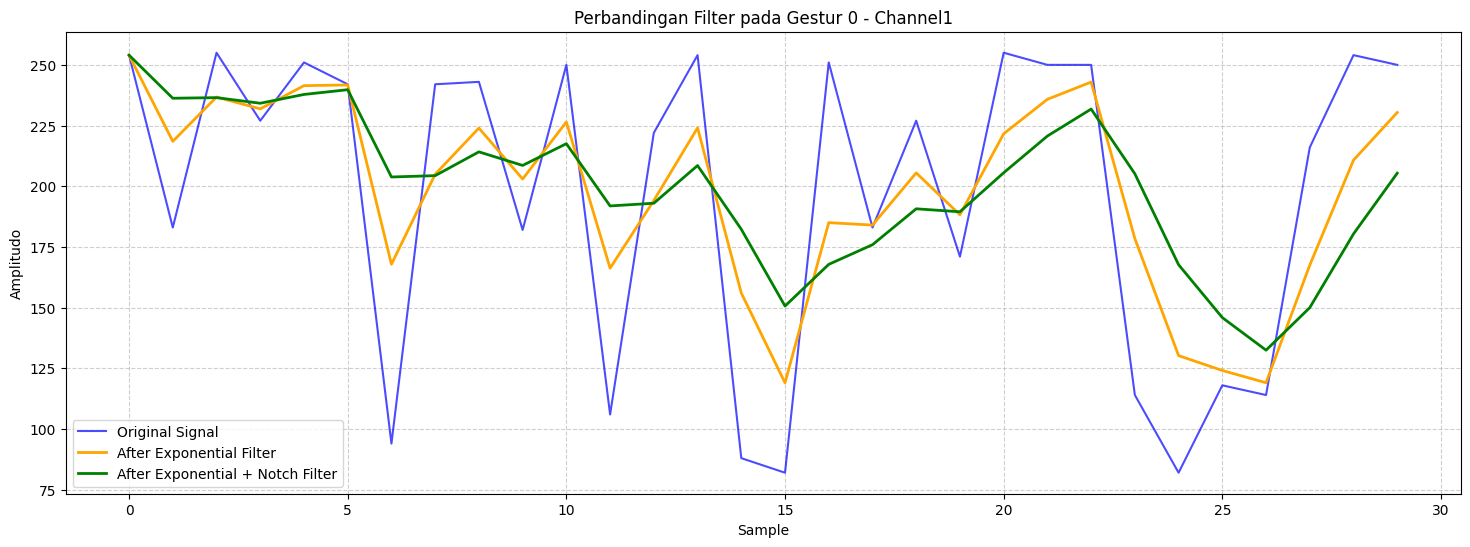

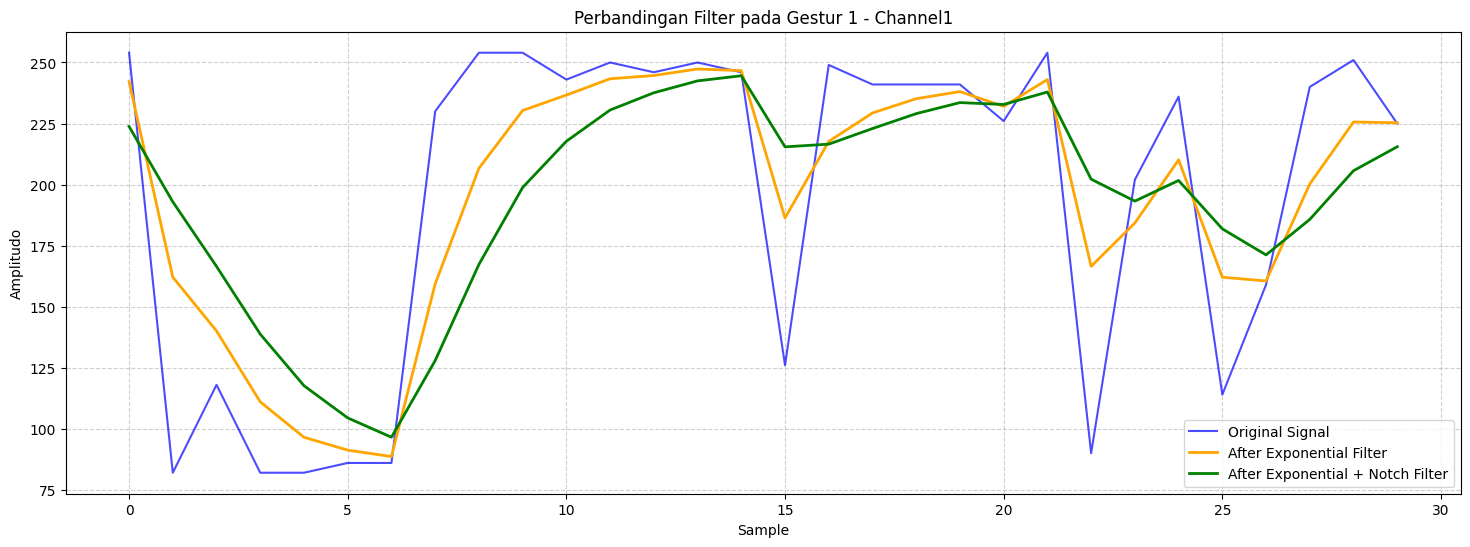

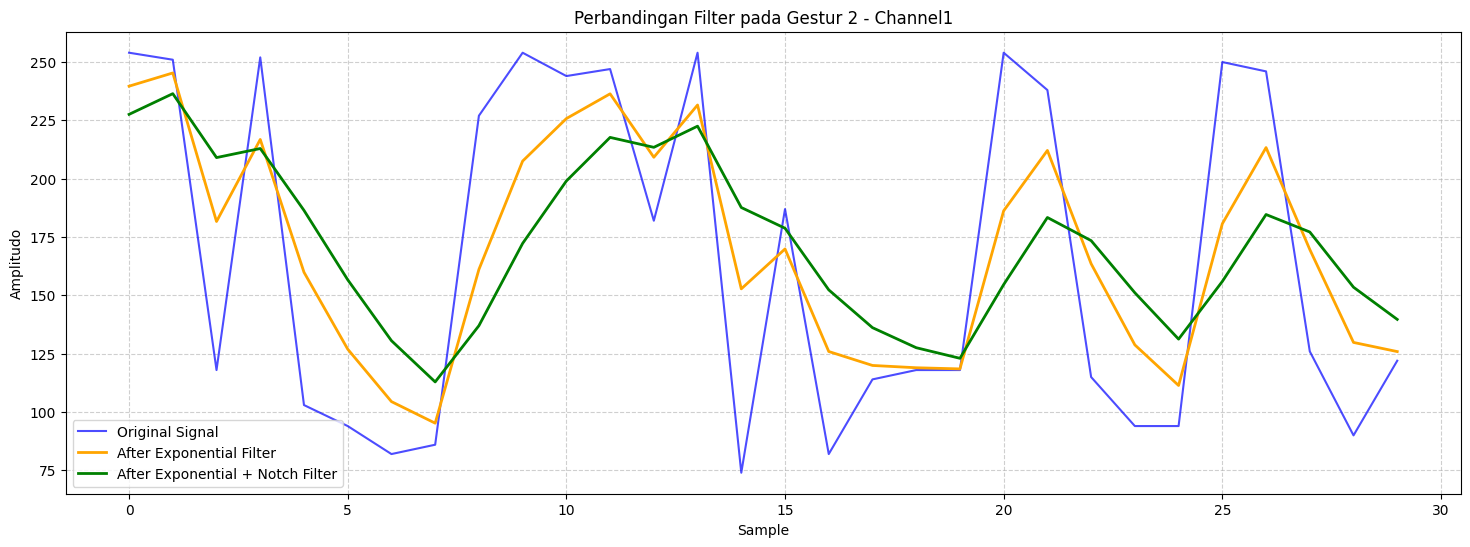

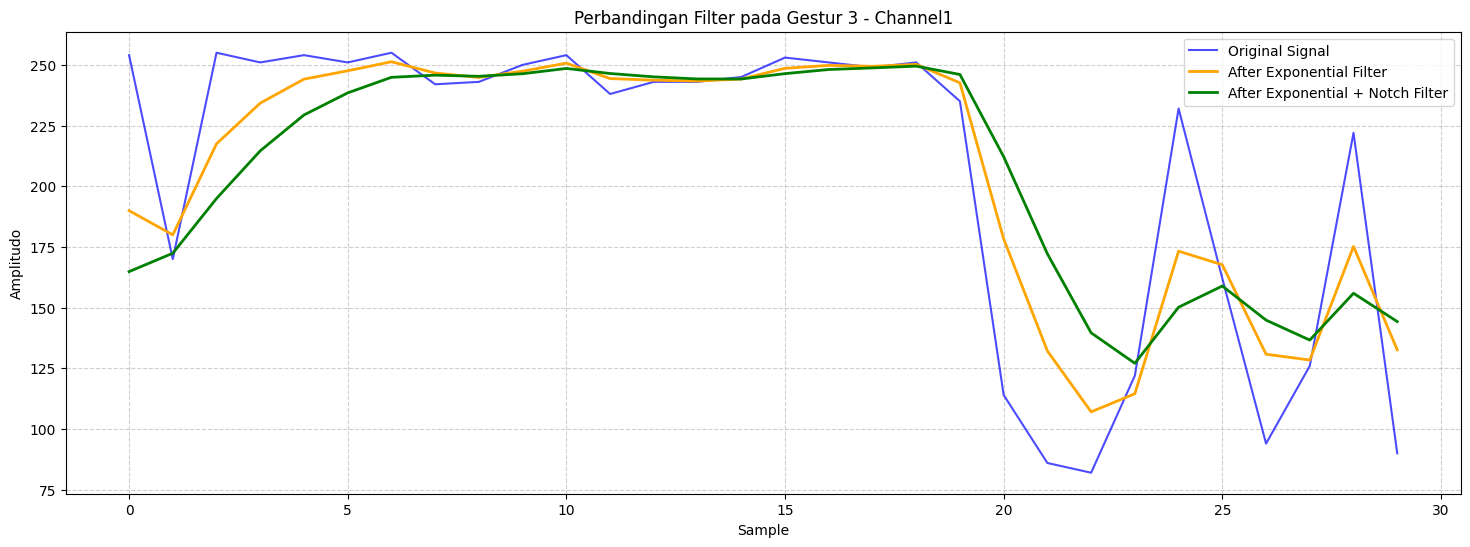

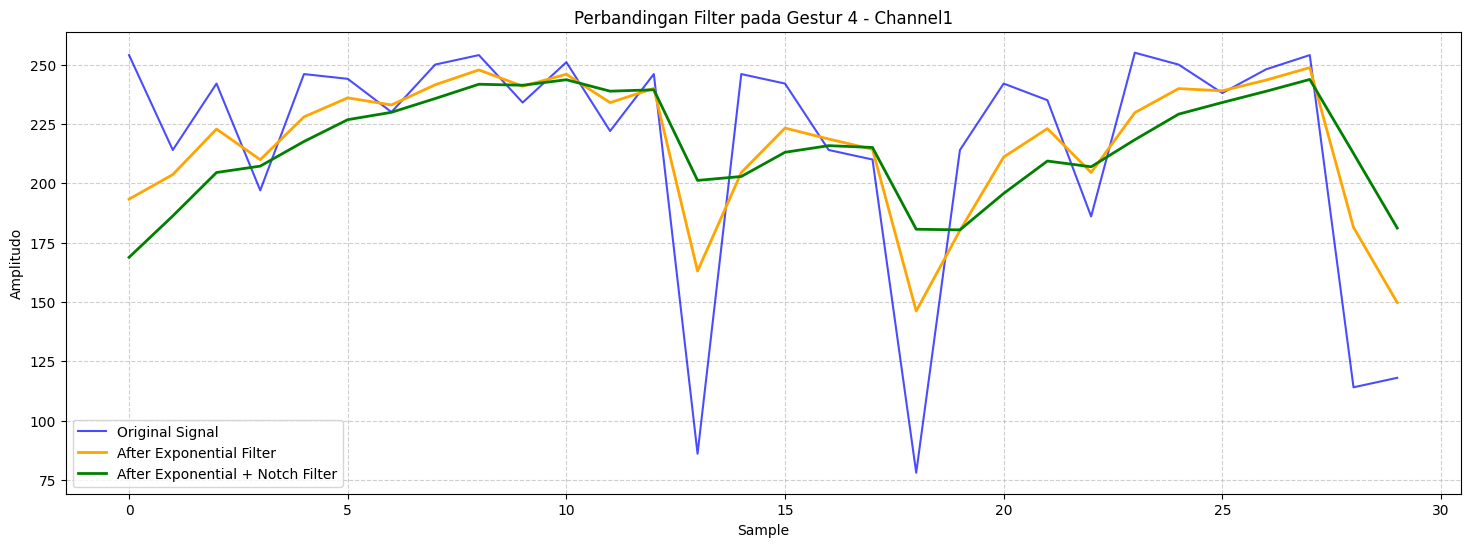

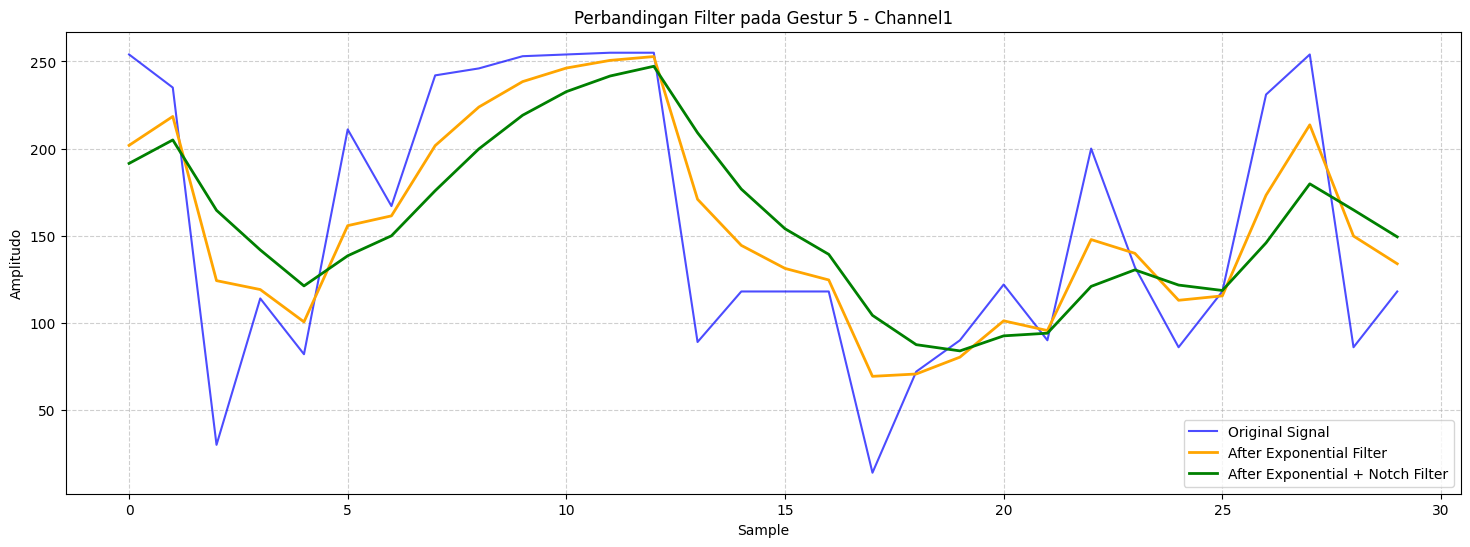

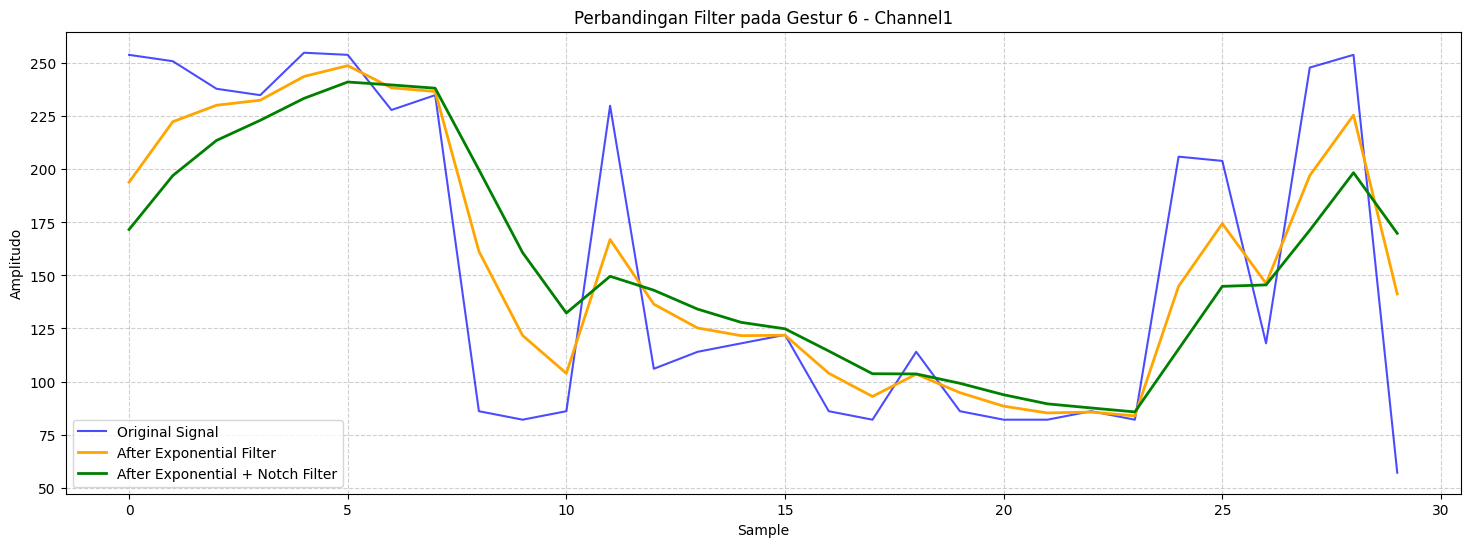

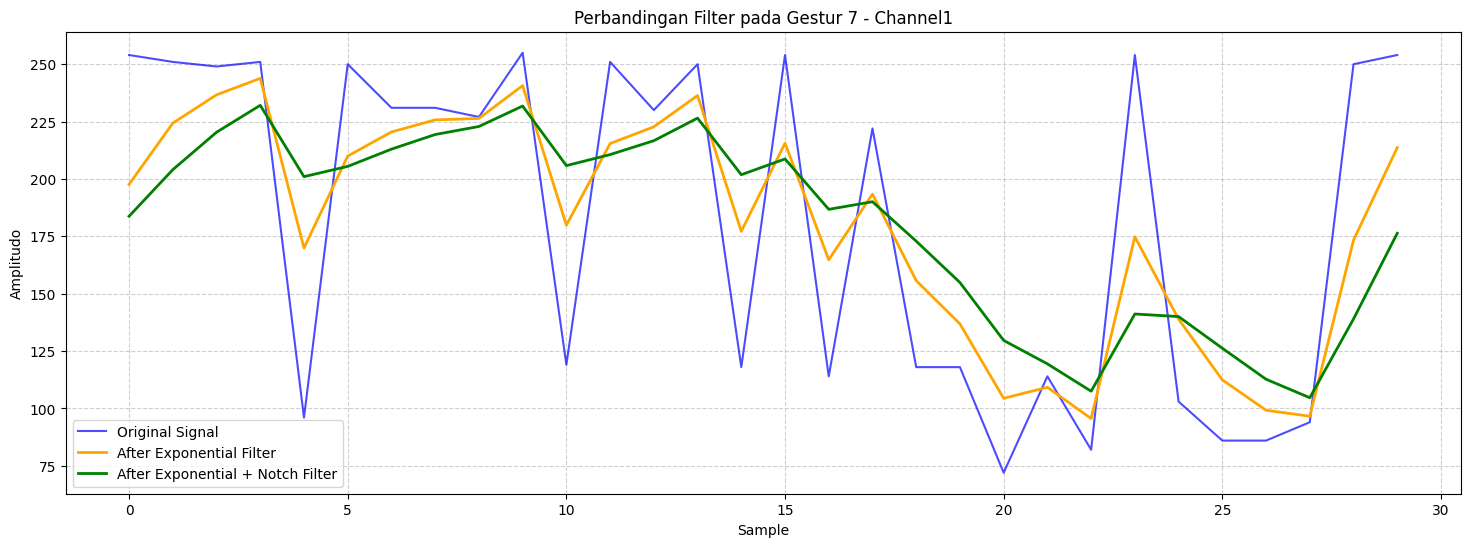

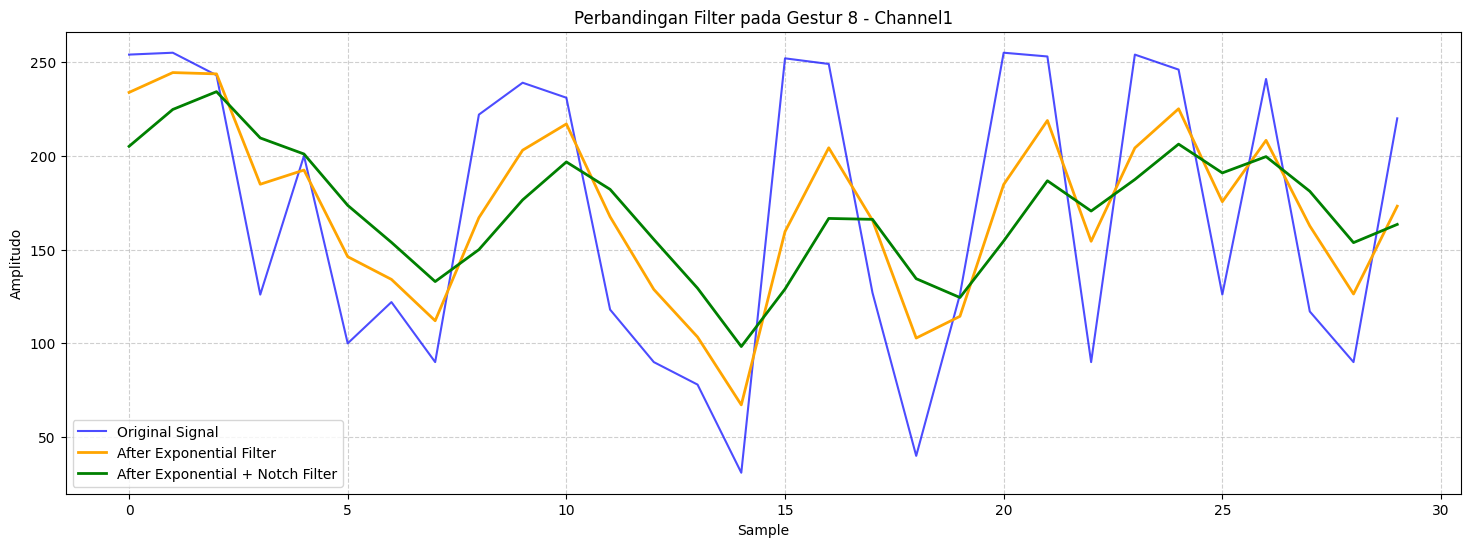

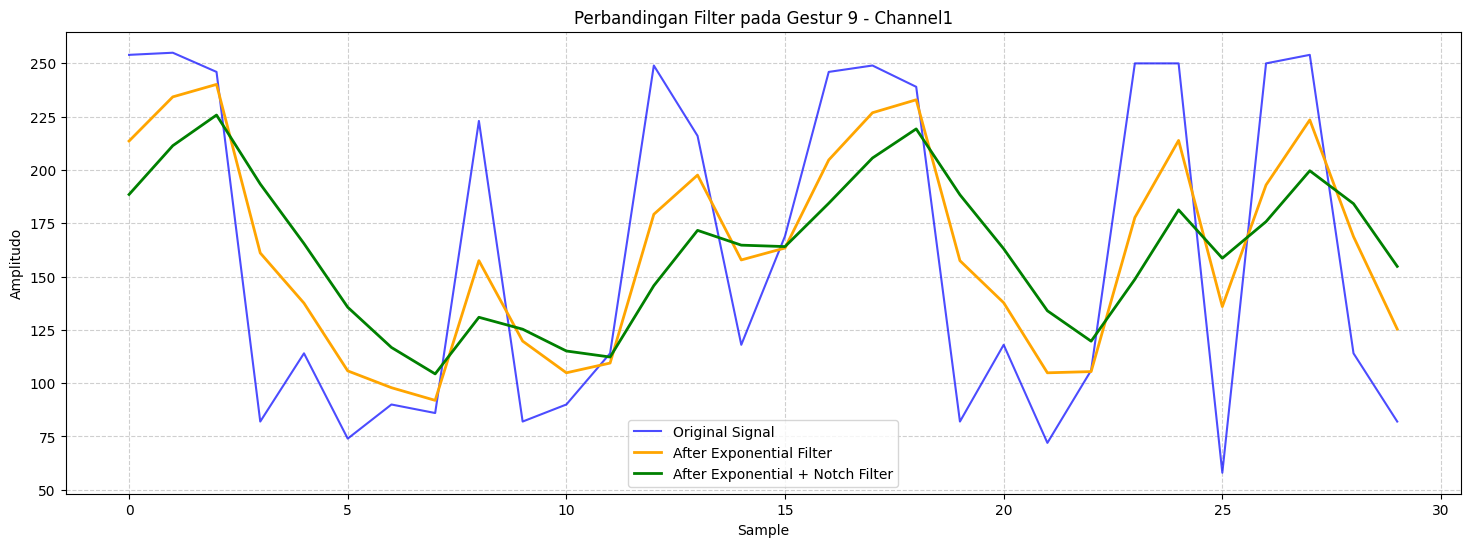

In [ ]:
# Pilih subjek dan channel untuk difokuskan
subject_id_to_plot = 1
channel_to_plot = 'Channel1'

print(f"Menampilkan Visualisasi Filter untuk Subjek {subject_id_to_plot}, Channel {channel_to_plot}, di Semua Gestur")

# Buat temporary dataframe untuk hasil exponential filter saja (untuk perbandingan)
# (Ini kita perlukan agar bisa membandingkan 3 tahap: original, exp only, exp+notch)
exp_filtered_only = data.copy()
for channel in emg_channels:
    exp_filtered_only[channel] = exponential_filter(exp_filtered_only[channel].values)

# Loop untuk setiap gestur
for gesture_class in range(num_classes):
    # Ambil data untuk subjek dan gestur yang dipilih
    original_subset = data[(data['Label'] == subject_id_to_plot) & (data['Class'] == gesture_class)]
    exp_filtered_subset = exp_filtered_only[(exp_filtered_only['Label'] == subject_id_to_plot) & (exp_filtered_only['Class'] == gesture_class)]
    final_filtered_subset = filtered_data[(filtered_data['Label'] == subject_id_to_plot) & (data['Class'] == gesture_class)] # filtered_data sudah berisi hasil exp+notch

    # Pastikan ada data untuk di-plot
    if original_subset.empty:
        print(f"Tidak ada data untuk Gestur {gesture_class} pada Subjek {subject_id_to_plot}. Plot dilewati.")
        continue

    # Ambil 300 data points pertama untuk kejelasan plot
    original_signal = original_subset[channel_to_plot].values[:300]
    exp_filtered_signal = exp_filtered_subset[channel_to_plot].values[:300]
    notch_filtered_signal = final_filtered_subset[channel_to_plot].values[:300]

    # Membuat plot
    plt.figure(figsize=(18, 6))
    plt.plot(original_signal, label='Original Signal', color='blue', alpha=0.7, linewidth=1.5)
    plt.plot(exp_filtered_signal, label='After Exponential Filter', color='orange', linewidth=2)
    plt.plot(notch_filtered_signal, label='After Exponential + Notch Filter', color='green', linewidth=2)

    plt.title(f'Perbandingan Filter pada Gestur {gesture_class} - {channel_to_plot}')
    plt.xlabel('Sample')
    plt.ylabel('Amplitudo')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

### **Tahap 4: Segmentasi Sinyal**

Memotong sinyal kontinu menjadi segmen-segmen (windows) yang lebih kecil Setiap segmen akan menjadi satu sampel data untuk model.

#### **Adjacent Windowing**

In [ ]:
all_segments_list = []
all_labels_list = []

window_size = 15 # Misalnya, 3 detik dengan fs=100 Hz atau 1.5 detik dengan fs=200 Hz
overlap = 0

# Pastikan data diurutkan berdasarkan Label dan Class untuk membuat aliran sinyal kontinu per subjek dan gestur
data_sorted = filtered_data.sort_values(by=['Label', 'Class']).reset_index(drop=True)

# Loop melalui setiap subjek dan setiap kelas gestur untuk memproses data secara berurutan
for label_id in data_sorted['Label'].unique():
    for gesture_class in data_sorted['Class'].unique():
        subset_df = data_sorted[(data_sorted['Label'] == label_id) & (data_sorted['Class'] == gesture_class)]

        if len(subset_df) < window_size:
            continue

        # Terapkan Adjacent Windowing dengan overlap
        for i in range(0, len(subset_df) - window_size + 1, window_size - overlap):
            segment_data = subset_df.iloc[i:i + window_size][emg_channels].values
            all_segments_list.append(segment_data)
            all_labels_list.append(gesture_class)

# Ubah list menjadi numpy array
all_segments = np.array(all_segments_list)
all_labels = np.array(all_labels_list)

# Verifikasi Hasil Segmentasi
if all_segments.shape[0] > 0:
    print(f"Total segmen yang dibuat dari semua subjek: {all_segments.shape[0]}")
    print(f"Bentuk satu segmen: {all_segments[0].shape}")
else:
    print("Tidak ada segmen yang berhasil dibuat. Periksa kembali logika filter atau subsetting.")

Total segmen yang dibuat dari semua subjek: 200
Bentuk satu segmen: (15, 8)


#### **Visualisasi Hasil Segmentasi**

In [ ]:
print("Menampilkan Visualisasi Segmen Pertama untuk Setiap Gestur (Subjek 1)")

subject_id = 1

# Loop untuk setiap gestur
for gesture_class in range(num_classes):
    # Cari indeks pertama dari segmen yang sesuai dengan subjek dan gestur
    # Kita cari di data original untuk mendapatkan indeks yang benar
    original_subset_indices = data[(data['Label'] == subject_id) & (data['Class'] == gesture_class)].index

    if not original_subset_indices.empty:
        # setiap 300 baris adalah satu blok, jadi kita cari blok ke berapa
        # Setiap subjek punya 10 gestur, jadi blok gestur 0 ada di indeks 0, gestur 1 di indeks 1, dst.
        segment_index_to_plot = (subject_id - 1) * 10 + gesture_class

        segment_to_plot = all_segments[segment_index_to_plot]

        # Buat sumbu waktu yang sesuai
        num_samples = segment_to_plot.shape[0]
        duration = num_samples / fs
        time_axis = np.linspace(0, duration, num_samples)

        # Buat figure BARU untuk setiap gestur
        plt.figure(figsize=(18, 6))

        # Plot setiap channel
        for i in range(segment_to_plot.shape[1]): # Loop sebanyak 8 channel
            plt.plot(time_axis, segment_to_plot[:, i], label=f'Channel {i+1}', linewidth=1.5)

        plt.title(f'Visualisasi Sinyal untuk Gestur Kelas {gesture_class}')
        plt.xlabel('Waktu (detik)')
        plt.ylabel('Amplitudo (Setelah Filter)')
        plt.legend(loc='upper right', fontsize='small')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()
    else:
        print(f'Tidak ada data untuk Gestur Kelas {gesture_class} pada Subjek {subject_id}.')

Output hidden; open in https://colab.research.google.com to view.

### **Tahap 5: Feature Extraction**

Menghitung fitur MAV, RMS, dan Amplitudo dari setiap segmen. Fitur-fitur ini akan menjadi input untuk setiap stream pada model CNN.

In [ ]:
# Fungsi untuk menghitung fitur dari semua segmen
def calculate_features(segments):
    # Mean Absolute Value (MAV)
    mav_features = np.mean(np.abs(segments), axis=1)
    # Root Mean Square (RMS)
    rms_features = np.sqrt(np.mean(segments**2, axis=1))
    # Amplitude (Max absolute value)
    amplitude_features = np.max(np.abs(segments), axis=1)
    return mav_features, rms_features, amplitude_features

# Ekstrak fitur dari semua segmen
X_mav, X_rms, X_amplitude = calculate_features(all_segments)

# Menampilkan bentuk dari array fitur
print("Bentuk array fitur MAV:", X_mav.shape)
print("Bentuk array fitur RMS:", X_rms.shape)
print("Bentuk array fitur Amplitude:", X_amplitude.shape)

# Menampilkan contoh hasil ekstraksi fitur untuk 5 segmen pertama
print("\nContoh Fitur MAV (5 segmen pertama):")
print(pd.DataFrame(X_mav[:5], columns=emg_channels))

print("\nContoh Fitur RMS (5 segmen pertama):")
print(pd.DataFrame(X_rms[:5], columns=emg_channels))

print("\nContoh Fitur Amplitude (5 segmen pertama):")
print(pd.DataFrame(X_amplitude[:5], columns=emg_channels))

Bentuk array fitur MAV: (200, 8)
Bentuk array fitur RMS: (200, 8)
Bentuk array fitur Amplitude: (200, 8)

Contoh Fitur MAV (5 segmen pertama):
     Channel1    Channel2    Channel3    Channel4    Channel5    Channel6  \
0  217.512472  164.147892  202.551440  165.452897  187.824491  133.829671   
1  181.303220  158.678608  181.423585  178.361530  185.118879  170.885687   
2  180.502101  169.765168  168.343706  199.855573  178.028916  164.030128   
3  209.694443  147.491158  216.214557  136.958997  202.663729  152.408577   
4  188.157040  122.700013  191.827830  150.137672  215.217769  156.747688   

     Channel7    Channel8  
0  210.127991  161.953426  
1  173.802250  187.814506  
2  204.274589  159.899276  
3  214.212613  147.550473  
4  218.346028  148.932252  

Contoh Fitur RMS (5 segmen pertama):
     Channel1    Channel2    Channel3    Channel4    Channel5    Channel6  \
0  218.469491  166.299419  206.645672  169.403173  192.963045  142.149704   
1  183.486269  160.817709  184.389

In [ ]:
# Data Augmentation dengan Menambahkan Noise
def augment_data(features, labels, factor=2, noise_level=0.01):
    augmented_features = [features]
    augmented_labels = [labels]
    for _ in range(factor - 1):
        noise = np.random.normal(0, noise_level, features.shape)
        augmented_features.append(features + noise)
        augmented_labels.append(labels)
    return np.vstack(augmented_features), np.concatenate(augmented_labels)

# Perbanyak data kita 10x lipat
X_mav_aug, y_aug = augment_data(X_mav, all_labels)
X_rms_aug, _ = augment_data(X_rms, all_labels)
X_amp_aug, _ = augment_data(X_amplitude, all_labels)
print(f"Jumlah data setelah augmentasi: {X_mav_aug.shape[0]}")

Jumlah data setelah augmentasi: 400


In [ ]:
# Normalisasi Data
scaler = StandardScaler()
X_mav_scaled = scaler.fit_transform(X_mav_aug)
X_rms_scaled = scaler.fit_transform(X_rms_aug)
X_amp_scaled = scaler.fit_transform(X_amp_aug)

# Menampilkan contoh hasil setelah normalisasi
print("Contoh Fitur MAV setelah dinormalisasi:")
print(pd.DataFrame(X_mav_scaled[:5], columns=emg_channels))

Contoh Fitur MAV setelah dinormalisasi:
   Channel1  Channel2  Channel3  Channel4  Channel5  Channel6  Channel7  \
0  0.798815 -0.523378  0.297673 -0.477592 -0.216178 -1.526787  0.611687   
1 -0.441753 -0.692389 -0.439722 -0.072447 -0.305373 -0.366412 -0.637966   
2 -0.469200 -0.349795 -0.896230  0.602157 -0.539108 -0.581088  0.410323   
3  0.530961 -1.038101  0.774537 -1.371891  0.273026 -0.945006  0.752204   
4 -0.206934 -1.804192 -0.076597 -0.958270  0.686894 -0.809131  0.894399   

   Channel8  
0 -0.607795  
1  0.190915  
2 -0.671237  
3 -1.052626  
4 -1.009950  


### **Tahap 6: Modeling Multi-Stream 3D CNN**

#### Persiapan Data untuk Model

In [ ]:
# Reshape Fitur untuk 3D CNN
# (jumlah sampel, kedalaman, tinggi, lebar, channel)
# Input akan menjadi (jumlah_segmen, 1, 8, 1, 1) -> Dimensi 'kedalaman' dan 'lebar' dari CNN 3D akan dimanfaatkan oleh 1x1x1 kernel
X_mav_3d = np.expand_dims(np.expand_dims(np.expand_dims(X_mav_scaled, axis=-1), axis=1), axis=1)
X_rms_3d = np.expand_dims(np.expand_dims(np.expand_dims(X_rms_scaled, axis=-1), axis=1), axis=1)
X_amp_3d = np.expand_dims(np.expand_dims(np.expand_dims(X_amp_scaled, axis=-1), axis=1), axis=1)

y = to_categorical(y_aug, num_classes=num_classes)

print(f"Bentuk data MAV setelah di-reshape untuk 3D CNN: {X_mav_3d.shape}")
print(f"Bentuk data RMS setelah di-reshape untuk 3D CNN: {X_rms_3d.shape}")
print(f"Bentuk data AMP setelah di-reshape untuk 3D CNN: {X_amp_3d.shape}")

Bentuk data MAV setelah di-reshape untuk 3D CNN: (400, 1, 1, 8, 1)
Bentuk data RMS setelah di-reshape untuk 3D CNN: (400, 1, 1, 8, 1)
Bentuk data AMP setelah di-reshape untuk 3D CNN: (400, 1, 1, 8, 1)


In [ ]:
# Split Data
# Membagi data menjadi training dan testing set (80:20)
X_train_mav, X_test_mav, y_train, y_test = train_test_split(X_mav_3d, y, test_size=0.2, random_state=42, stratify=y)
X_train_rms, X_test_rms, _, _ = train_test_split(X_rms_3d, y, test_size=0.2, random_state=42, stratify=y)
X_train_amp, X_test_amp, _, _ = train_test_split(X_amp_3d, y, test_size=0.2, random_state=42, stratify=y)

#### Membangun Arsitektur Model

In [ ]:
# Membangun Arsitektur Multi-Stream 3D CNN
def create_3d_cnn_stream(input_shape, stream_name):
    input_layer = Input(shape=input_shape, name=stream_name)

    # Lapisan Konvolusi 3D
    x = Conv3D(32, kernel_size=(1, 3, 3), activation='relu', padding='same')(input_layer) # Direvisi
    # Adjusted pooling size to be compatible with input dimension
    x = MaxPooling3D(pool_size=(1, 1, 2))(x) # Direvisi

    x = Conv3D(64, kernel_size=(1, 3, 3), activation='relu', padding='same')(x) # Direvisi
    # Adjusted pooling size to be compatible with input dimension after first pooling
    x = MaxPooling3D(pool_size=(1, 1, 2))(x) # Direvisi

    x = Flatten()(x)
    return input_layer, x

# Dapatkan input shape dari data yang sudah di-reshape
input_shape_3d = X_train_mav.shape[1:]

# Membuat 3 stream
input_mav, stream_mav = create_3d_cnn_stream(input_shape_3d, 'input_mav')
input_rms, stream_rms = create_3d_cnn_stream(input_shape_3d, 'input_rms')
input_amp, stream_amp = create_3d_cnn_stream(input_shape_3d, 'input_amplitude')

# Menggabungkan output dari ketiga stream
combined = concatenate([stream_mav, stream_rms, stream_amp])

# Lapisan Fully Connected
x = Dense(512, activation='relu')(combined) # Direvisi
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x) # Direvisi
x = Dropout(0.5)(x)

# Lapisan output
output = Dense(num_classes, activation='softmax')(x)

# Membuat model akhir
model = Model(inputs=[input_mav, input_rms, input_amp], outputs=output)

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_mav           │ (None, 1, 1, 8,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_rms           │ (None, 1, 1, 8,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_amplitude     │ (None, 1, 1, 8,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_6 (Conv3D)   │ (None, 1, 1, 8,   │        320 │ input_mav[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_8 (Conv3D)   │ (None, 1, 1, 8,   │        320 │ input_rms[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_10 (Conv3D)  │ (None, 1, 1, 8,   │        320 │ input_amplitude[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_6     │ (None, 1, 1, 4,   │          0 │ conv3d_6[0][0]    │
│ (MaxPooling3D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_8     │ (None, 1, 1, 4,   │          0 │ conv3d_8[0][0]    │
│ (MaxPooling3D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_10    │ (None, 1, 1, 4,   │          0 │ conv3d_10[0][0]   │
│ (MaxPooling3D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_7 (Conv3D)   │ (None, 1, 1, 4,   │     18,496 │ max_pooling3d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_9 (Conv3D)   │ (None, 1, 1, 4,   │     18,496 │ max_pooling3d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_11 (Conv3D)  │ (None, 1, 1, 4,   │     18,496 │ max_pooling3d_10… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_7     │ (None, 1, 1, 2,   │          0 │ conv3d_7[0][0]    │
│ (MaxPooling3D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_9     │ (None, 1, 1, 2,   │          0 │ conv3d_9[0][0]    │
│ (MaxPooling3D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_11    │ (None, 1, 1, 2,   │          0 │ conv3d_11[0][0]   │
│ (MaxPooling3D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 128)       │          0 │ max_pooling3d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 128)       │          0 │ max_pooling3d_9[… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 320,522 (1.22 MB)

 Trainable params: 320,522 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

#### Melatih Model

In [ ]:
# Melatih model
history = model.fit(
    [X_train_mav, X_train_rms, X_train_amp],
    y_train,
    epochs=150,
    batch_size=32,
    validation_data=([X_test_mav, X_test_rms, X_test_amp], y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)]
)

Epoch 1/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.1250 - loss: 2.2970 - val_accuracy: 0.1250 - val_loss: 2.2930
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1017 - loss: 2.3020 - val_accuracy: 0.1250 - val_loss: 2.2900
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1077 - loss: 2.2979 - val_accuracy: 0.1250 - val_loss: 2.2873
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1474 - loss: 2.2711 - val_accuracy: 0.1500 - val_loss: 2.2835
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1701 - loss: 2.2654 - val_accuracy: 0.1625 - val_loss: 2.2782
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1780 - loss: 2.2515 - val_accuracy: 0.2000 - val_loss: 2.2733
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2022 - loss: 2.2386 - val_accuracy: 0.2125 - val_loss: 2.2684
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1888 - loss: 2.2269 - val_accuracy: 0.

### **Tahap 7: Model Evaluation**

#### Prediksi dan Laporan Klasifikasi

In [ ]:
# Melakukan prediksi pada data test
y_pred_probs = model.predict([X_test_mav, X_test_rms, X_test_amp])
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


In [ ]:
# --- Menampilkan Classification Report per Gestur ---
print('--- Classification Report per Gestur ---')
# Buat dictionary untuk nama gestur agar laporan lebih mudah dibaca
gesture_names = {
    0: "Open", 1: "Close", 2: "Fine Grip", 3: "Pointer",
    4: "Agree", 5: "Two", 6: "Three", 7: "Four",
    8: "Pinch", 9: "Half Close"
}

for i in range(num_classes):
    # Buat label biner untuk kelas saat ini (kelas i vs. bukan kelas i)
    y_true_binary = (y_true_classes == i)
    y_pred_binary = (y_pred_classes == i)

    gesture_name = gesture_names.get(i, f"Gestur Kelas {i}")

    print(f'\n--- Laporan untuk {gesture_name} ---')
    print(classification_report(y_true_binary, y_pred_binary, target_names=[f'Bukan Gestur Ini', f'Gestur Ini']))

--- Classification Report per Gestur ---

--- Laporan untuk Open ---
                  precision    recall  f1-score   support

Bukan Gestur Ini       0.95      0.97      0.96        72
      Gestur Ini       0.67      0.50      0.57         8

        accuracy                           0.93        80
       macro avg       0.81      0.74      0.77        80
    weighted avg       0.92      0.93      0.92        80


--- Laporan untuk Close ---
                  precision    recall  f1-score   support

Bukan Gestur Ini       1.00      0.99      0.99        72
      Gestur Ini       0.89      1.00      0.94         8

        accuracy                           0.99        80
       macro avg       0.94      0.99      0.97        80
    weighted avg       0.99      0.99      0.99        80


--- Laporan untuk Fine Grip ---
                  precision    recall  f1-score   support

Bukan Gestur Ini       1.00      1.00      1.00        72
      Gestur Ini       1.00      1.00      1.00   

In [ ]:
# --- Menampilkan Classification Report Keseluruhan ---
print('--- Overall Classification Report ---')
gesture_names = {
    0: "Open", 1: "Close", 2: "Fine Grip", 3: "Pointer",
    4: "Agree", 5: "Two", 6: "Three", 7: "Four",
    8: "Pinch", 9: "Half Close"
}
print(classification_report(y_true_classes, y_pred_classes, target_names=[gesture_names.get(i, str(i)) for i in range(num_classes)]))

--- Overall Classification Report ---
              precision    recall  f1-score   support

        Open       0.67      0.50      0.57         8
       Close       0.89      1.00      0.94         8
   Fine Grip       1.00      1.00      1.00         8
     Pointer       0.78      0.88      0.82         8
       Agree       0.75      0.75      0.75         8
         Two       1.00      1.00      1.00         8
       Three       1.00      0.88      0.93         8
        Four       0.80      1.00      0.89         8
       Pinch       0.80      1.00      0.89         8
  Half Close       1.00      0.62      0.77         8

    accuracy                           0.86        80
   macro avg       0.87      0.86      0.86        80
weighted avg       0.87      0.86      0.86        80



#### Plot Hasil Training, Confusion Matrix, dan Kurva ROC

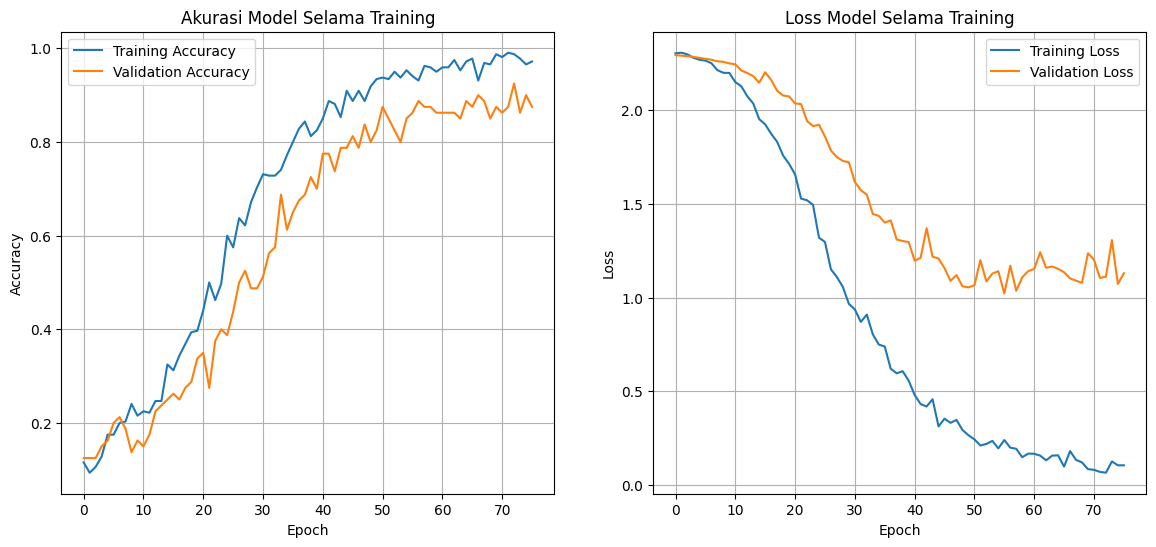

In [ ]:
# --- Visualisasi Hasil Training ---
plt.figure(figsize=(14, 6))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Akurasi Model Selama Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Model Selama Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

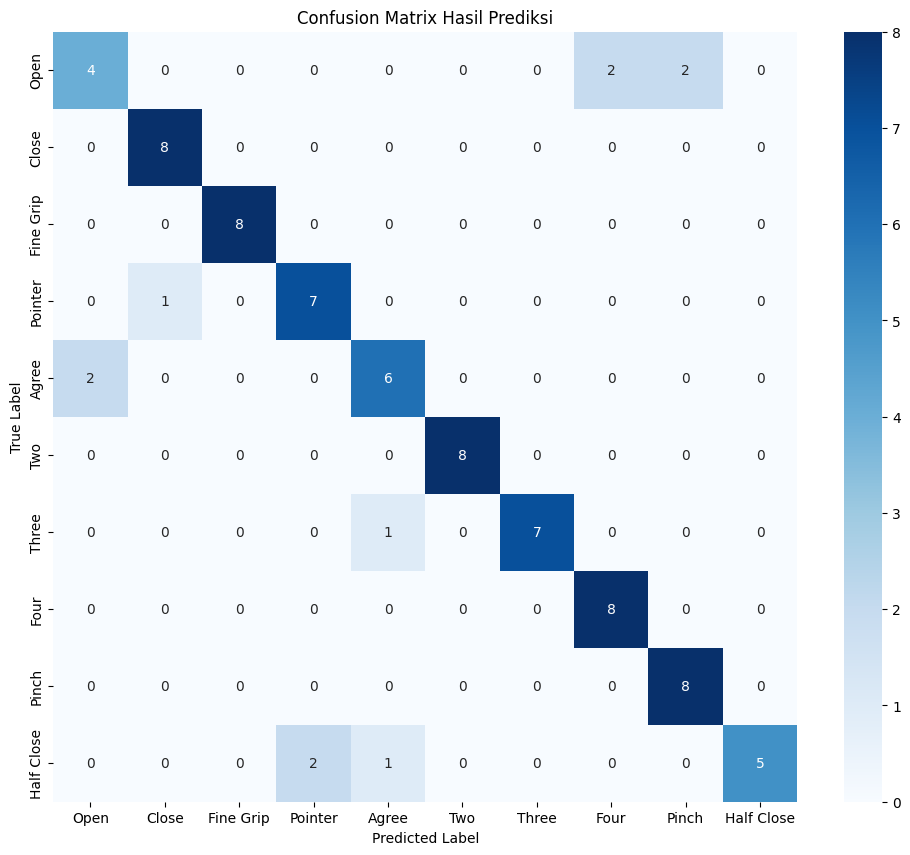

In [ ]:
# --- Plot Confusion Matrix ---
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[gesture_names.get(i, str(i)) for i in range(num_classes)],
            yticklabels=[gesture_names.get(i, str(i)) for i in range(num_classes)])
plt.title('Confusion Matrix Hasil Prediksi')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

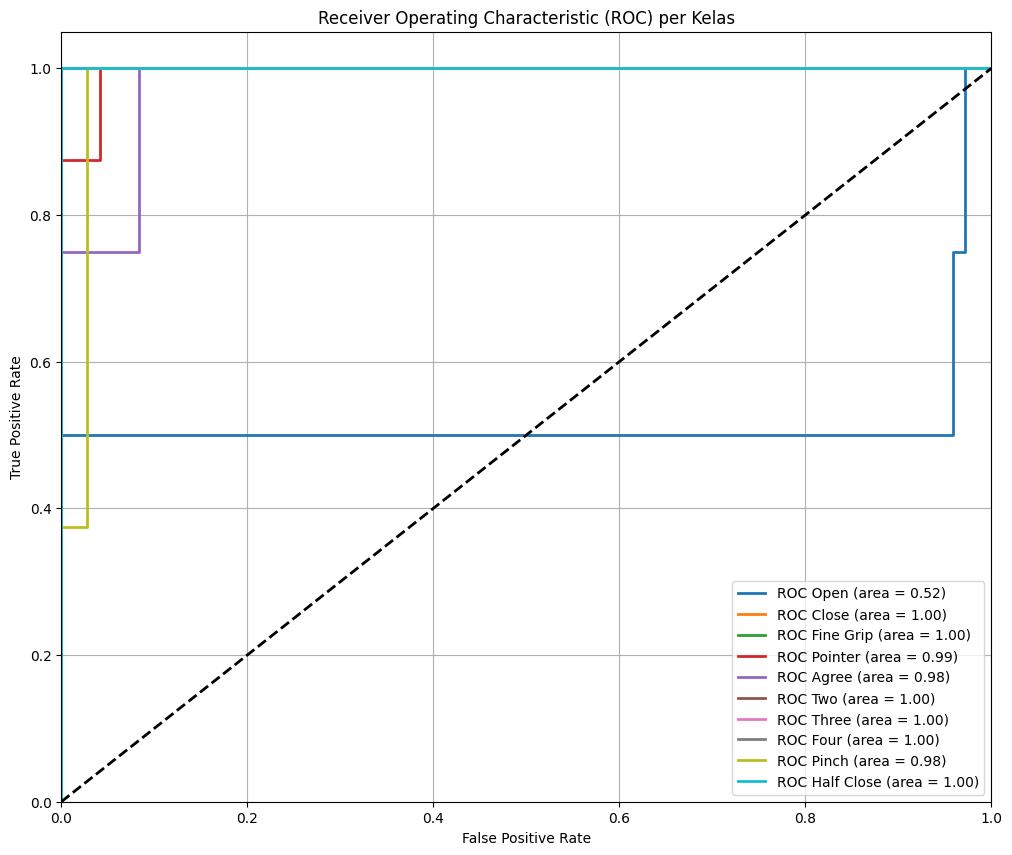

In [ ]:
# --- Plot Kurva ROC ---
plt.figure(figsize=(12, 10))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC {gesture_names.get(i, i)} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) per Kelas')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()